# Amazon Sale Report — Data Cleaning & EDA

This notebook takes a raw Amazon sales export (`data/Amazon Sale Report.csv`) and:

1. Looks at the raw data and finds missing values
2. Cleans / fills the missing values in a sensible way
3. Removes columns that are not useful
4. Explores the data with simple charts (order status, sales by category, sales over time, sales by state, order size, etc.)
5. Finds and treats outliers in `qty` and `amount`

All charts are also saved as PNG files in the `figures/` folder, in case you just want to look at pictures without running any code.

**Note:** the comments in this notebook are kept simple and basic on purpose — the goal is to explain *what* each step does, not to be a formal data-science write-up.

## 1. Import libraries
We use `pandas` for tables, `numpy` for numbers, and `seaborn`/`matplotlib` for charts.

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# make the charts show up nicely inside the notebook
%matplotlib inline


## 2. Load the dataset
The CSV file lives in `data/Amazon Sale Report.csv` (same project folder as this notebook).

In [1]:
df = pd.read_csv("../data/Amazon Sale Report.csv")
df.shape


(128975, 24)

A quick look at the column names, first few rows, and data types.

In [2]:
df.columns

['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']

In [ ]:
df.head()

In [ ]:
df.info()

## 3. Check for missing values
Before doing anything else, we check which columns have empty (`NaN`) cells.

In [ ]:
df.isnull().sum()

Lower-case the column names so we don't have to remember the exact capitalisation later (e.g. `Order ID` -> `order id`).

In [ ]:
df.columns = df.columns.str.lower()
df.columns

## 4. Fill in missing values

We go column by column and decide the simplest reasonable fix:

- **courier status** — missing mostly means "Cancelled" orders (no courier was ever assigned). If the order was cancelled we label it `cancelled`, otherwise we assume it was `Shipped`.
- **currency** — filled with the most common currency (the mode).
- **amount** — filled with the average amount for that product **category** (better than a single overall average).
- **ship-city / ship-state / ship-postal-code / ship-country** — filled with the most common city/state/country in the data, and postal code filled using the most common postal code for that city.
- **promotion-ids / fulfilled-by / unnamed: 22** — filled with the text `"Unknown"` since a missing value here is meaningful information on its own.

In [ ]:
def map_status(row):
    if pd.isna(row["courier status"]):
        if row["status"] == "cancelled":
            return "cancelled"
        else:
            return "Shipped"
    else:
        return row["courier status"]

df["courier status"] = df.apply(map_status, axis=1)
df["courier status"].isnull().sum()


In [ ]:
df["currency"] = df["currency"].fillna(df["currency"].mode()[0])


In [ ]:
# fill missing sales amount with the average amount for that product category
df["amount"] = df["amount"].fillna(df.groupby("category")["amount"].transform("mean"))


In [ ]:
df["ship-city"] = df["ship-city"].fillna("BENGALURU")
df["ship-country"] = df["ship-country"].fillna("IN")
df["ship-state"] = df["ship-state"].fillna("KARNATAKA")
df["ship-postal-code"] = df["ship-postal-code"].fillna("KARNATAKA")

# for postal code, fill using the most common postal code seen for that city
postal_map = df.groupby("ship-city")["ship-postal-code"].agg(lambda x: x.mode()[0])
df["ship-postal-code"] = df.apply(
    lambda row: postal_map[row["ship-city"]] if pd.isna(row["ship-postal-code"]) else row["ship-postal-code"],
    axis=1
)


In [ ]:
df["promotion-ids"] = df["promotion-ids"].fillna("Unknown")
df["unnamed: 22"] = df["unnamed: 22"].fillna("Unknown")
df["fulfilled-by"] = df["fulfilled-by"].fillna("Unknown")


Double check: no missing values should be left now.

In [3]:
df.isnull().sum()

## 5. Drop columns we don't need

- `unnamed: 22` was an empty/junk column from the original export.
- `promotion-ids` is mostly just "Unknown" or very long text, not useful for these charts.

We drop both.

In [ ]:
df = df.drop(columns=["unnamed: 22", "promotion-ids"])
df.info()

## 6. Explore: Order Status
How many orders are Shipped, Cancelled, Pending, etc.?

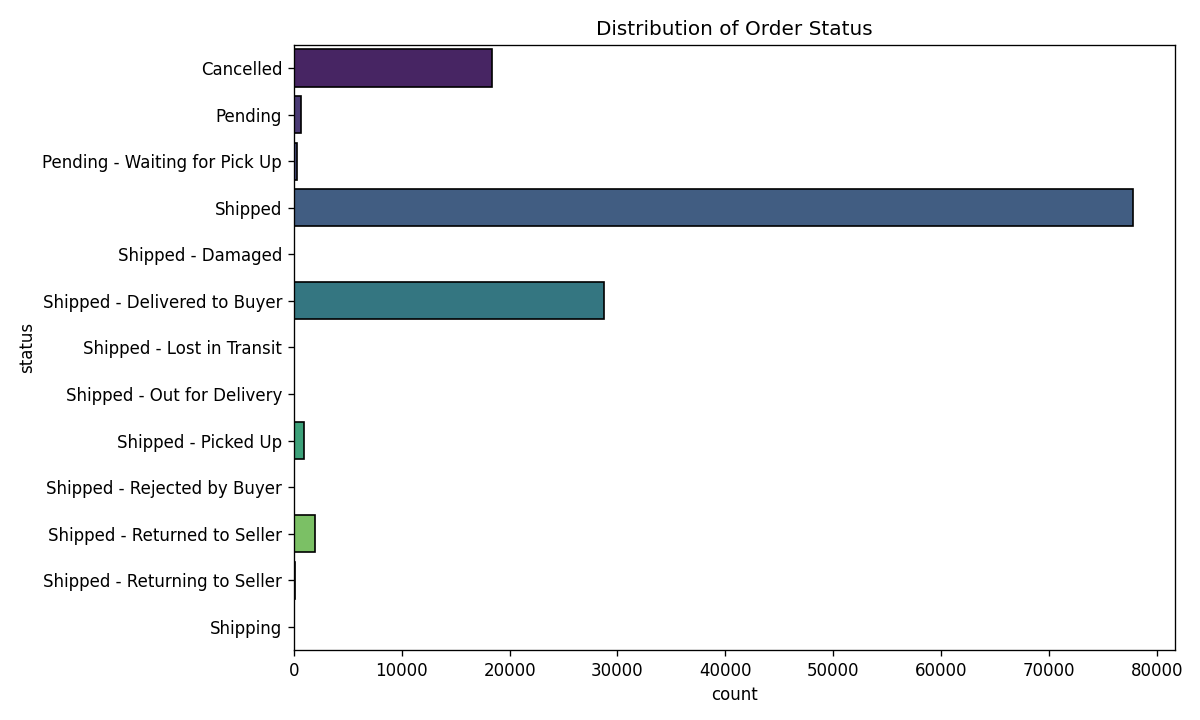

In [ ]:
grop = df.groupby("status").size().reset_index()
grop.columns = ["status", "count"]

plt.figure(figsize=(10, 6))
sns.barplot(y="status", x="count", data=grop, orient="h", edgecolor="black")
plt.title("Distribution of Order Status")
plt.tight_layout()
plt.savefig("../figures/01_order_status_distribution.png", dpi=120)
plt.show()


## 7. Order Status by Fulfilment Type
Does Amazon-fulfilled vs Merchant-fulfilled make a difference to how orders turn out?

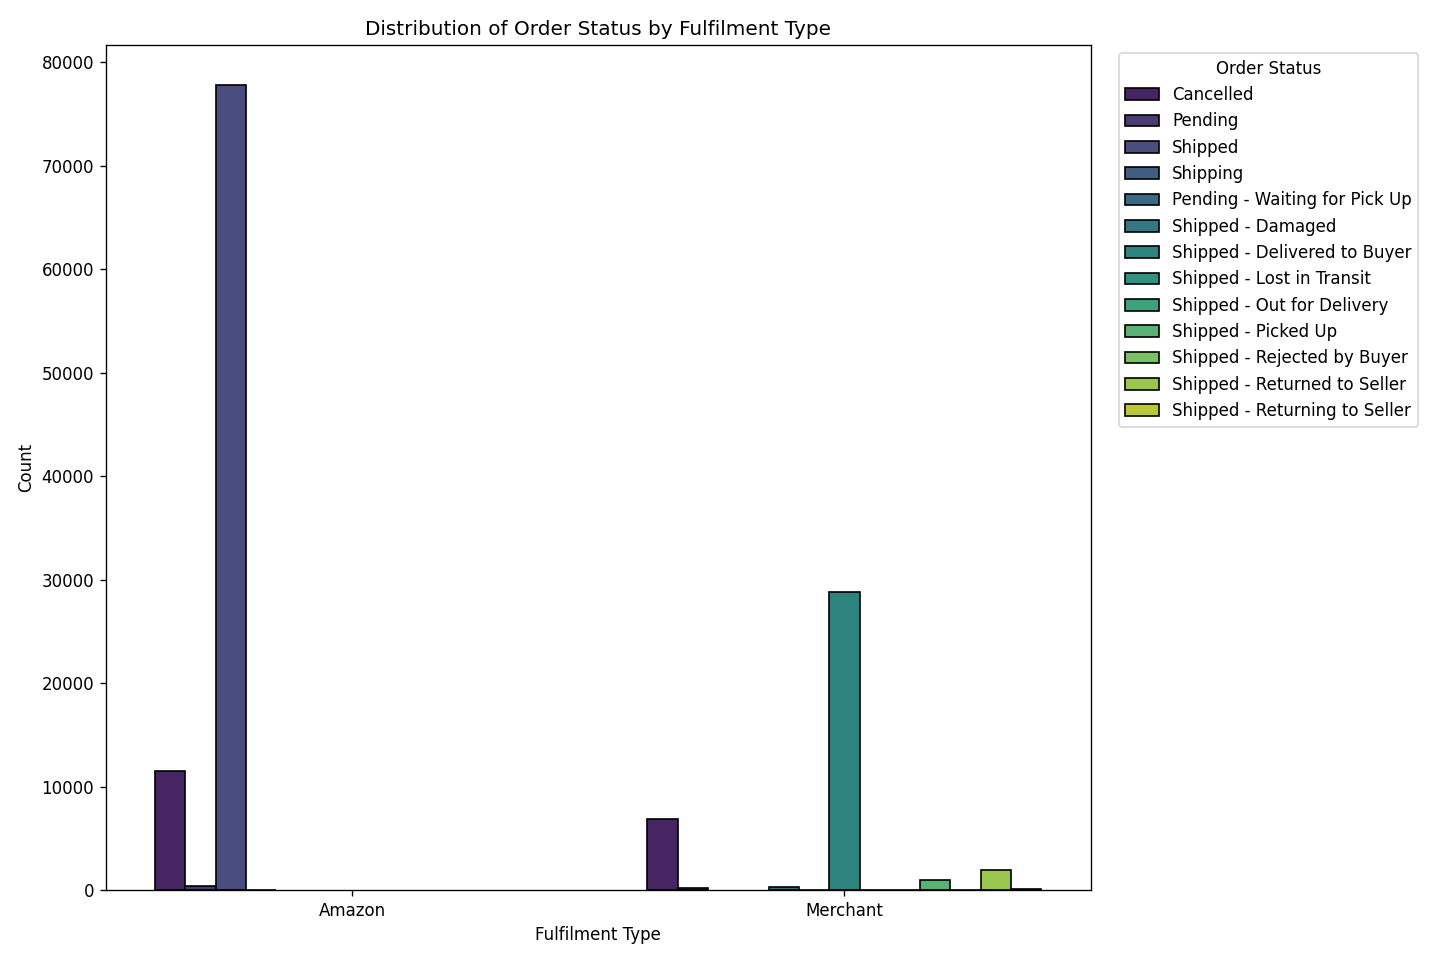

fulfilment                        status  count
    Amazon                     Cancelled  11471
    Amazon                       Pending    415
    Amazon                       Shipped  77804
    Amazon                      Shipping      8
  Merchant                     Cancelled   6861
  Merchant                       Pending    243
  Merchant Pending - Waiting for Pick Up    281
  Merchant             Shipped - Damaged      1
  Merchant  Shipped - Delivered to Buyer  28769
  Merchant     Shipped - Lost in Transit      5
  Merchant    Shipped - Out for Delivery     35
  Merchant           Shipped - Picked Up    973
  Merchant   Shipped - Rejected by Buyer     11
  Merchant  Shipped - Returned to Seller   1953
  Merchant Shipped - Returning to Seller    145


In [ ]:
grop2 = df.groupby(["fulfilment", "status"]).size().reset_index(name="count")

plt.figure(figsize=(12, 8))
sns.barplot(x="fulfilment", y="count", hue="status", data=grop2, edgecolor="black")
plt.title("Distribution of Order Status by Fulfilment Type")
plt.xlabel("Fulfilment Type")
plt.ylabel("Count")
plt.legend(title="Order Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../figures/02_order_status_by_fulfilment.png", dpi=120)
plt.show()
print(grop2)


A simple check of the success / cancel / problem rate for Merchant-fulfilled orders specifically.

In [ ]:
merchant_rows = grop2[grop2["fulfilment"] == "Merchant"]
total_from_m = int(merchant_rows["count"].sum())

shipped = merchant_rows.loc[merchant_rows["status"].str.contains("Shipped", case=False), "count"].sum()
cancelled = merchant_rows.loc[merchant_rows["status"] == "Cancelled", "count"].sum()
problem = total_from_m - shipped - cancelled

print(f"Total Merchant orders: {total_from_m}")
print(f"Success rate (Shipped): {shipped/total_from_m*100:.2f}%")
print(f"Cancel rate: {cancelled/total_from_m*100:.2f}%")
print(f"Other/problem rate: {problem/total_from_m*100:.2f}%")


Total Merchant orders: 39277
Success rate (Shipped): 81.20%
Cancel rate: 17.47%
Other/problem rate: 1.33%


## 8. Total Sales by Category
Which product category brings in the most total sales?

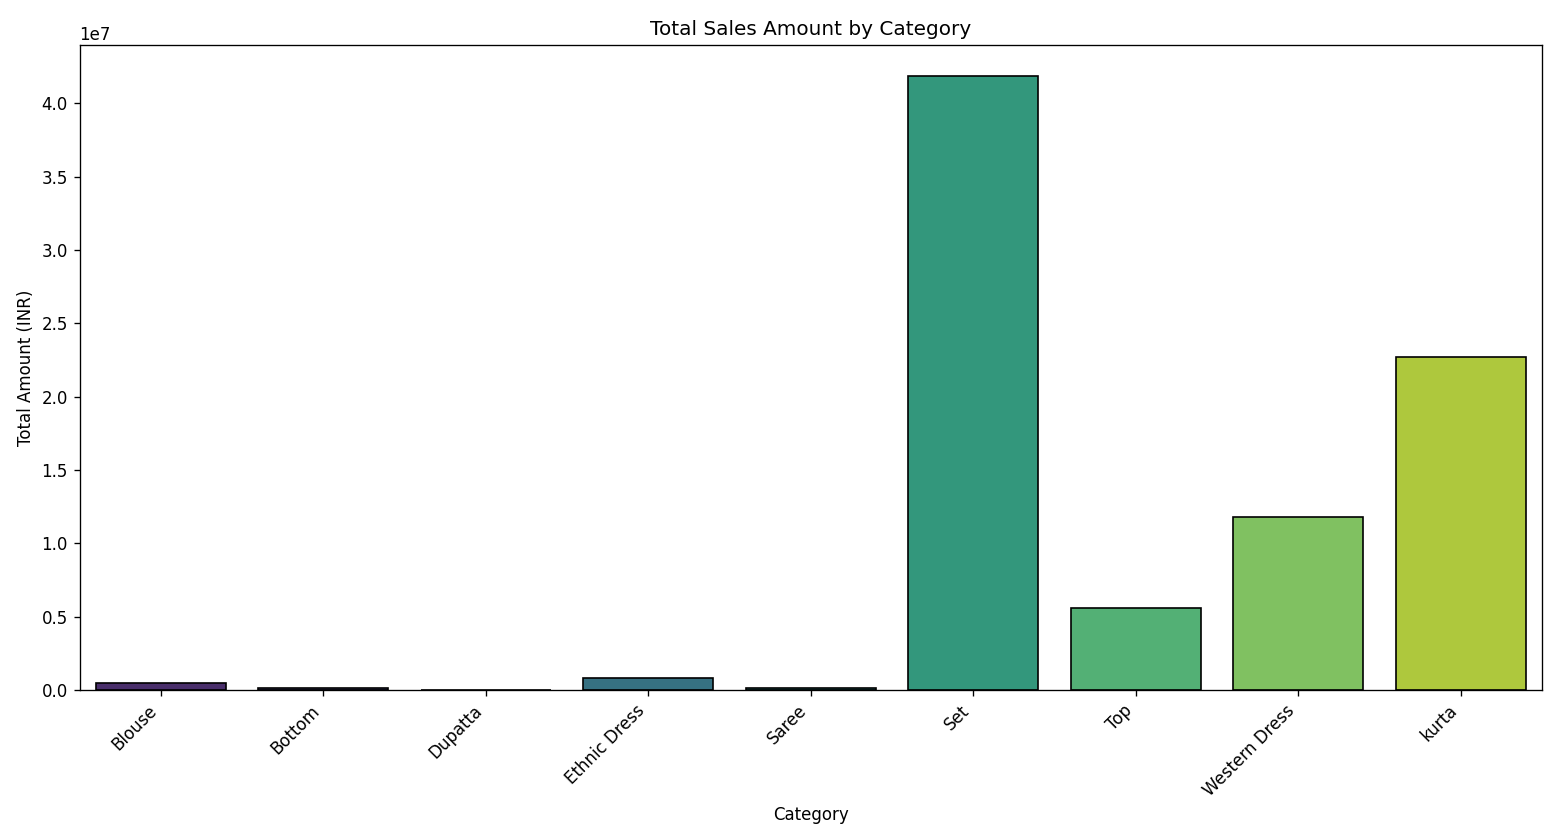

     category       amount
       Blouse 4.818229e+05
       Bottom 1.578426e+05
      Dupatta 9.150000e+02
 Ethnic Dress 8.389948e+05
        Saree 1.311299e+05
          Set 4.190596e+07
          Top 5.588219e+06
Western Dress 1.182325e+07
        kurta 2.274028e+07


In [ ]:
group = df.groupby("category")["amount"].sum().reset_index()

plt.figure(figsize=(13, 7))
sns.barplot(x="category", y="amount", data=group, edgecolor="black")
plt.title("Total Sales Amount by Category")
plt.xlabel("Category")
plt.ylabel("Total Amount (INR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/03_total_sales_by_category.png", dpi=120)
plt.show()
print(group)


## 9. Turn the date column into a real date
So we can group orders by month and by day.

In [ ]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["month"] = df["date"].dt.month


## 10. Orders by Month

month
3      171
4    49067
5    42040
6    37697
dtype: int64


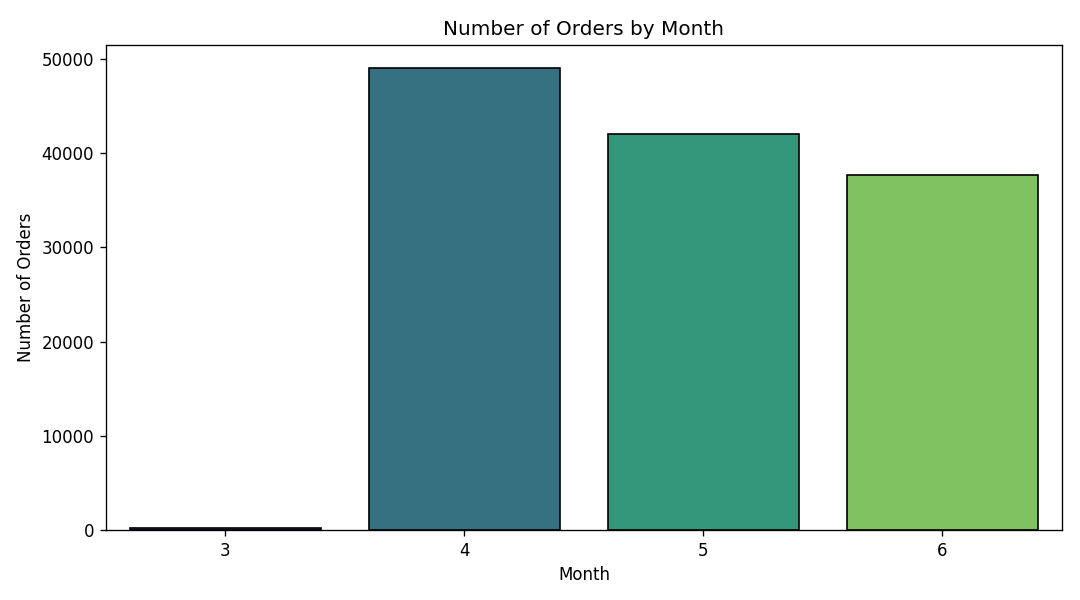

In [ ]:
sales_per_month = df.groupby("month").size()
print(sales_per_month)

plt.figure(figsize=(9, 5))
sns.countplot(x="month", data=df, edgecolor="black")
plt.title("Number of Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig("../figures/04_orders_by_month.png", dpi=120)
plt.show()


## 11. Daily Sales Timeline
How does the number of orders change day by day?

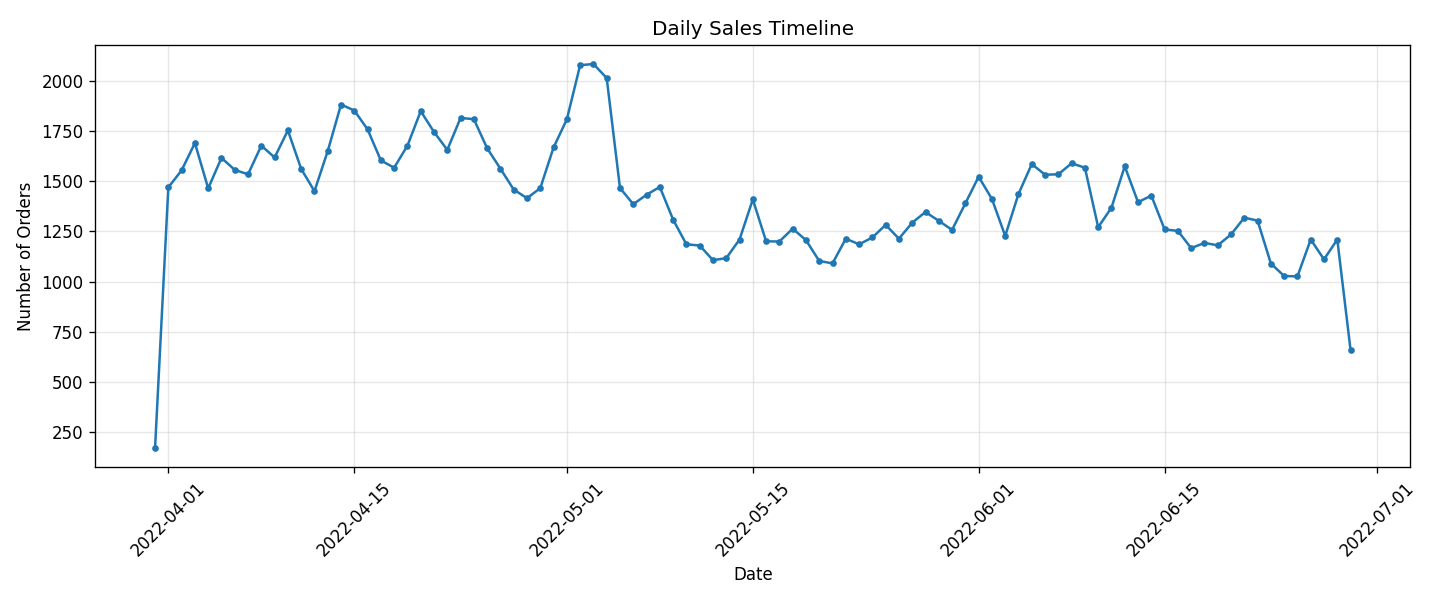

In [ ]:
daily_sales = df.groupby(df["date"].dt.date).size().reset_index(name="count")

plt.figure(figsize=(12, 5))
plt.plot(daily_sales["date"], daily_sales["count"], marker="o", markersize=3)
plt.title("Daily Sales Timeline")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/05_daily_sales_timeline.png", dpi=120)
plt.show()


## 12. Top 10 States by Sales
Which shipping states spend the most?

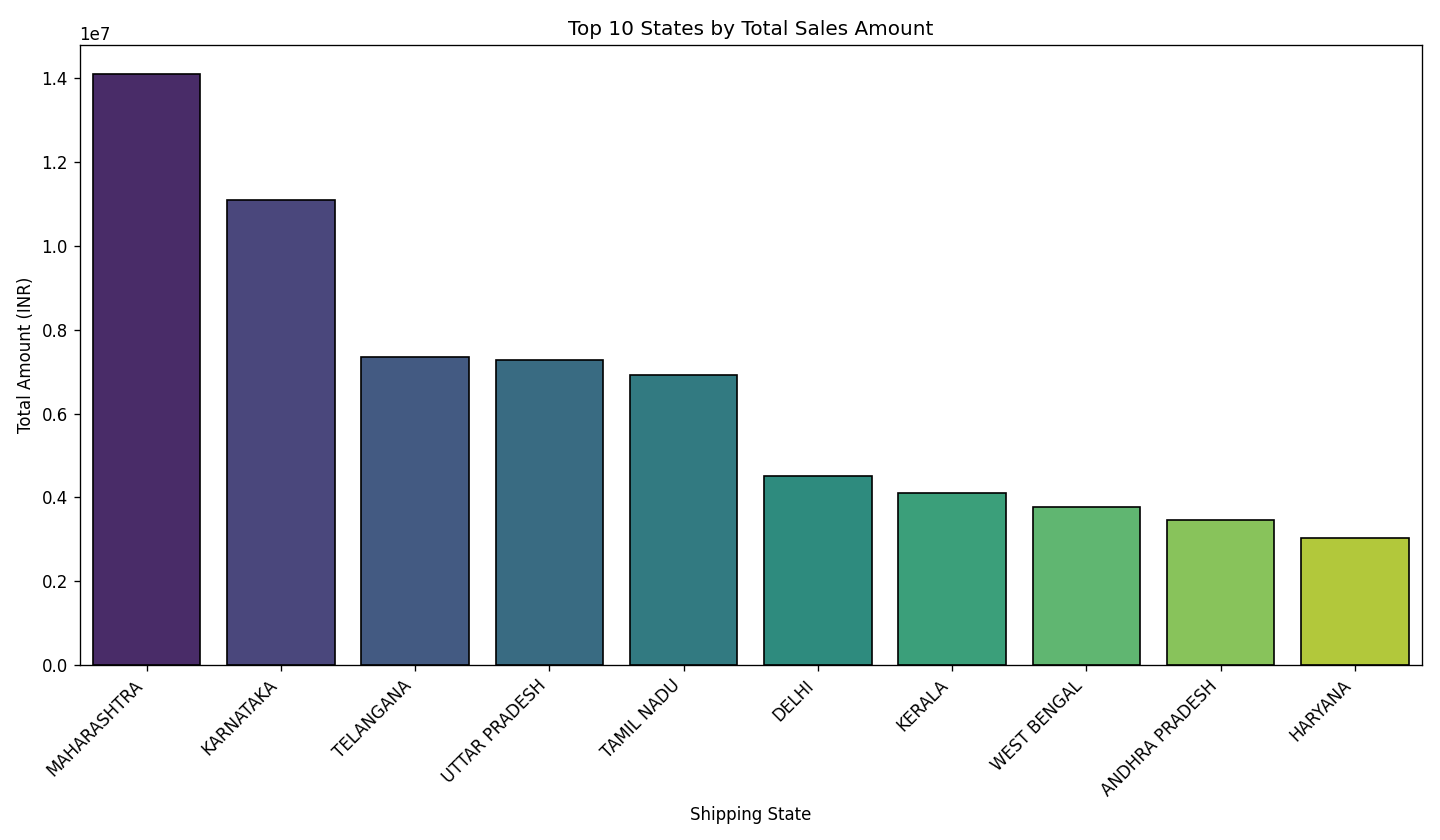

    ship-state       amount
   MAHARASHTRA 1.409624e+07
     KARNATAKA 1.110183e+07
     TELANGANA 7.360290e+06
 UTTAR PRADESH 7.290540e+06
    TAMIL NADU 6.914732e+06
         DELHI 4.502837e+06
        KERALA 4.103236e+06
   WEST BENGAL 3.771708e+06
ANDHRA PRADESH 3.457450e+06
       HARYANA 3.035168e+06


In [ ]:
grop_sat = (df.groupby("ship-state")["amount"]
              .sum()
              .reset_index()
              .sort_values("amount", ascending=False)
              .head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x="ship-state", y="amount", data=grop_sat, edgecolor="black")
plt.title("Top 10 States by Total Sales Amount")
plt.xlabel("Shipping State")
plt.ylabel("Total Amount (INR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/06_top10_states_by_sales.png", dpi=120)
plt.show()
print(grop_sat)


## 13. Sizes Sold per Category
Which sizes are most popular, and does that change per category?

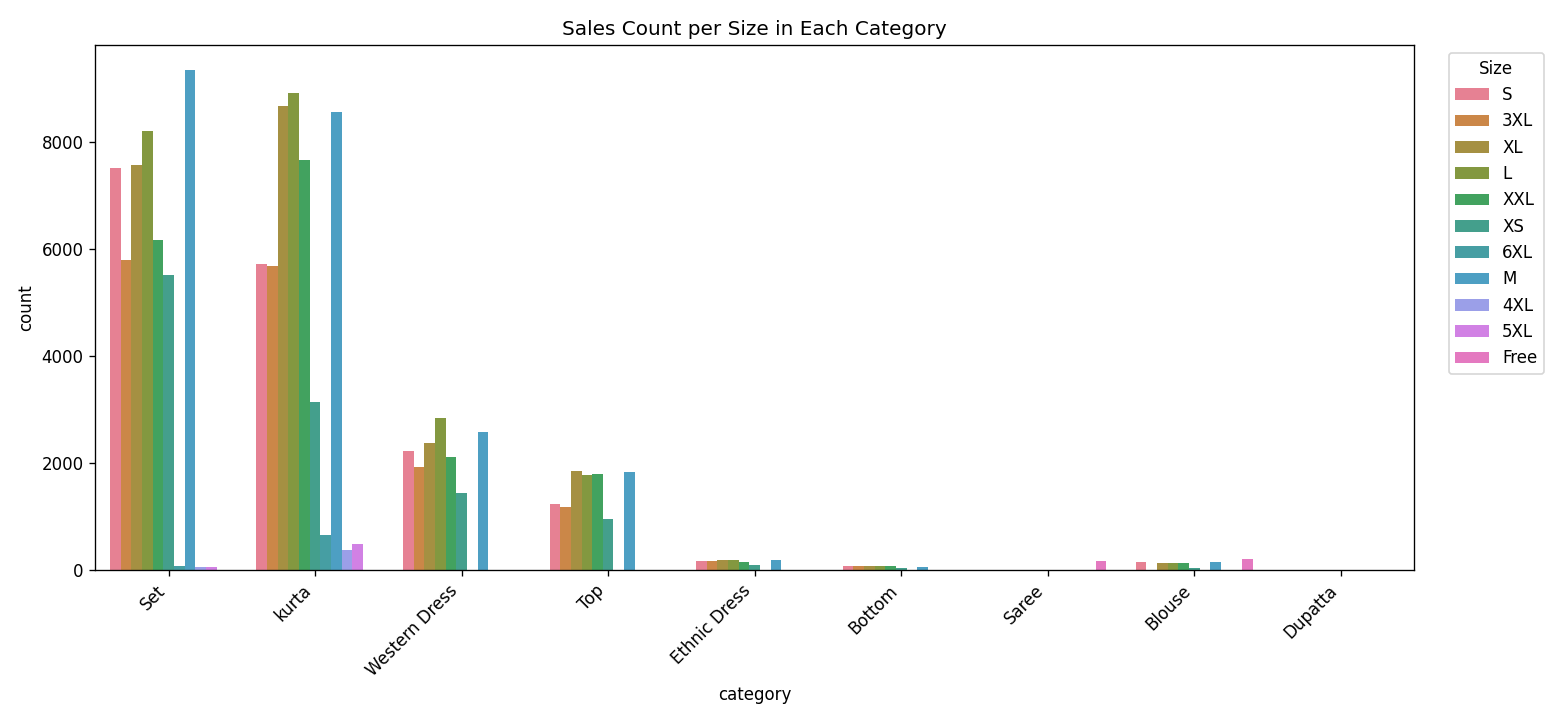

In [ ]:
pivot_ct = df.pivot_table(index="category", columns="size", aggfunc="size", fill_value=0)
print(pivot_ct)

plt.figure(figsize=(13, 6))
sns.countplot(data=df, x="category", hue="size")
plt.title("Sales Count per Size in Each Category")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Size", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../figures/07_size_by_category.png", dpi=120)
plt.show()


## 14. Outliers in `qty`

A boxplot is a simple way to spot outliers (points far outside the "whiskers"). We use the standard **IQR rule**:
anything outside `Q1 - 1.5*IQR` to `Q3 + 1.5*IQR` is capped (clipped) instead of removed, so we don't lose rows.

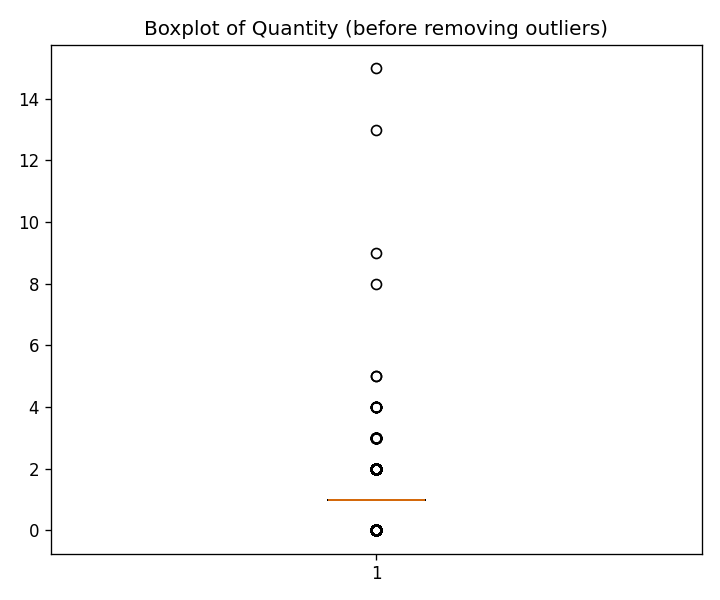

In [ ]:
plt.figure(figsize=(6, 5))
plt.boxplot(df["qty"])
plt.title("Boxplot of Quantity (before removing outliers)")
plt.tight_layout()
plt.savefig("../figures/08_qty_boxplot_before.png", dpi=120)
plt.show()


In [ ]:
Q1 = df["qty"].quantile(0.25)
Q3 = df["qty"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

df["qty"] = df["qty"].clip(lower=lower_bound, upper=upper_bound)


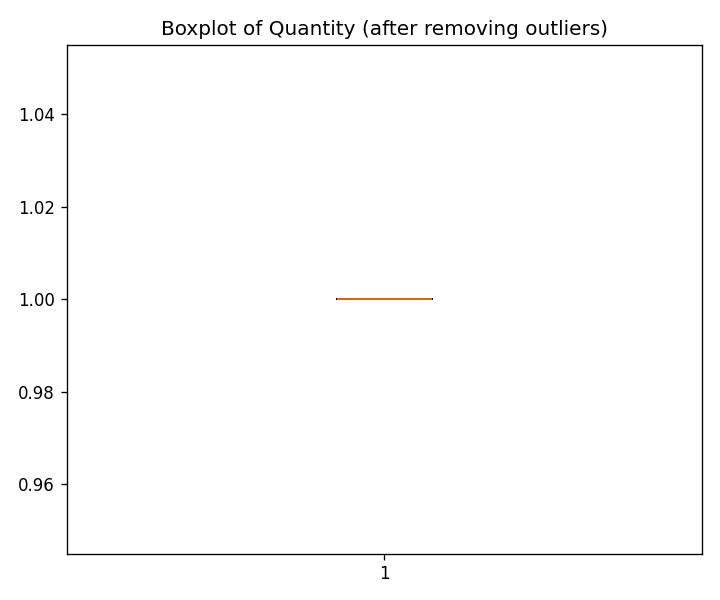

In [ ]:
plt.figure(figsize=(6, 5))
plt.boxplot(df["qty"])
plt.title("Boxplot of Quantity (after removing outliers)")
plt.tight_layout()
plt.savefig("../figures/09_qty_boxplot_after.png", dpi=120)
plt.show()


## 15. Outliers in `amount`
Same idea, this time on the sales amount column.

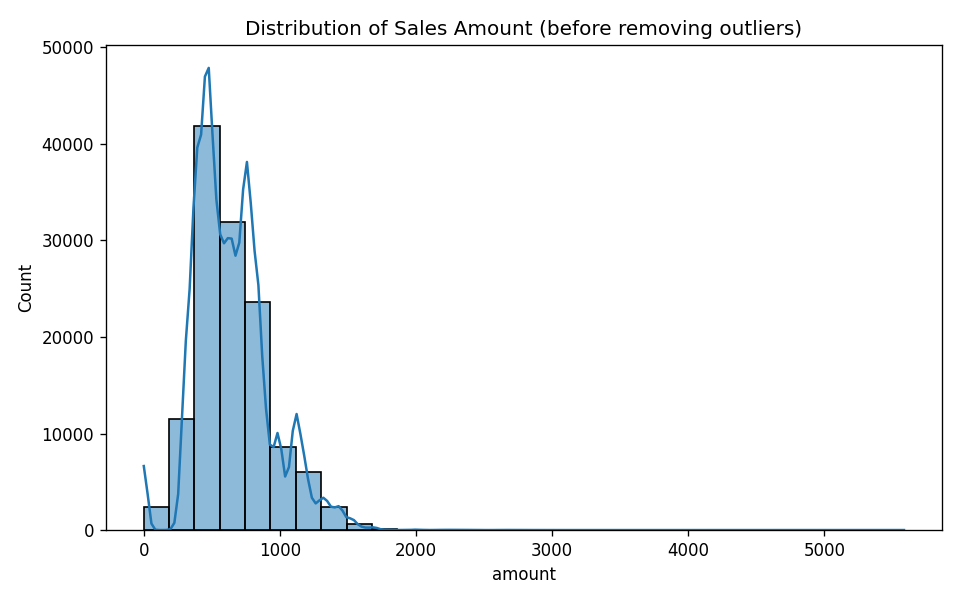

In [ ]:
sns.histplot(df["amount"], bins=30, kde=True)
plt.title("Distribution of Sales Amount (before removing outliers)")
plt.tight_layout()
plt.savefig("../figures/10_amount_distribution_before.png", dpi=120)
plt.show()


In [ ]:
Q1 = df["amount"].quantile(0.25)
Q3 = df["amount"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

df["amount"] = df["amount"].clip(lower=lower_bound, upper=upper_bound)


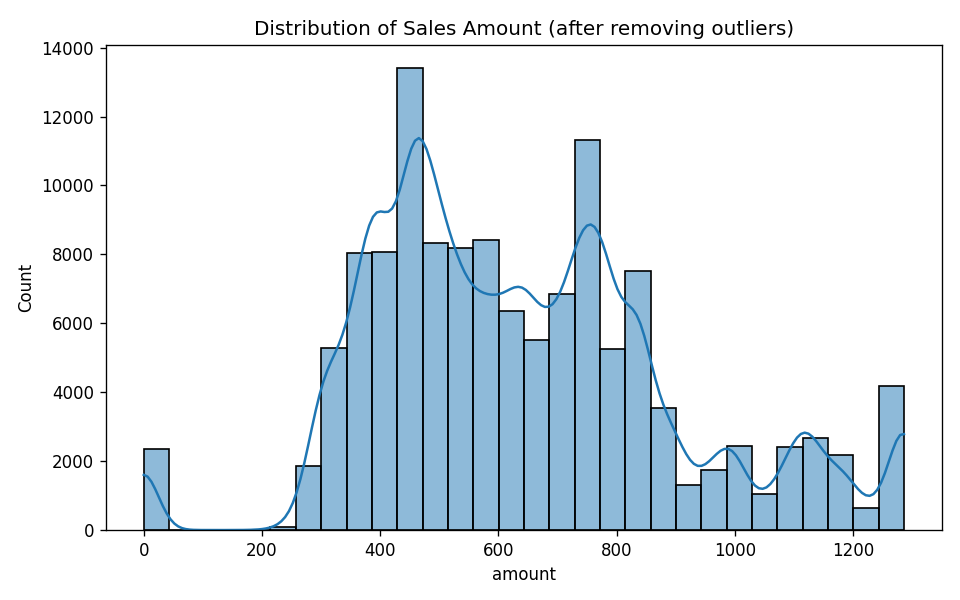

In [ ]:
sns.histplot(df["amount"], bins=30, kde=True)
plt.title("Distribution of Sales Amount (after removing outliers)")
plt.tight_layout()
plt.savefig("../figures/11_amount_distribution_after.png", dpi=120)
plt.show()


## 16. Average Sales by Category (after cleaning)
Now that outliers are capped, let's look at the average order value per category.

     category     amount
       Blouse 520.327106
       Bottom 358.733286
      Dupatta 305.000000
 Ethnic Dress 722.156888
        Saree 791.391718
          Set 823.303973
          Top 525.908420
Western Dress 761.669528
        kurta 455.748235


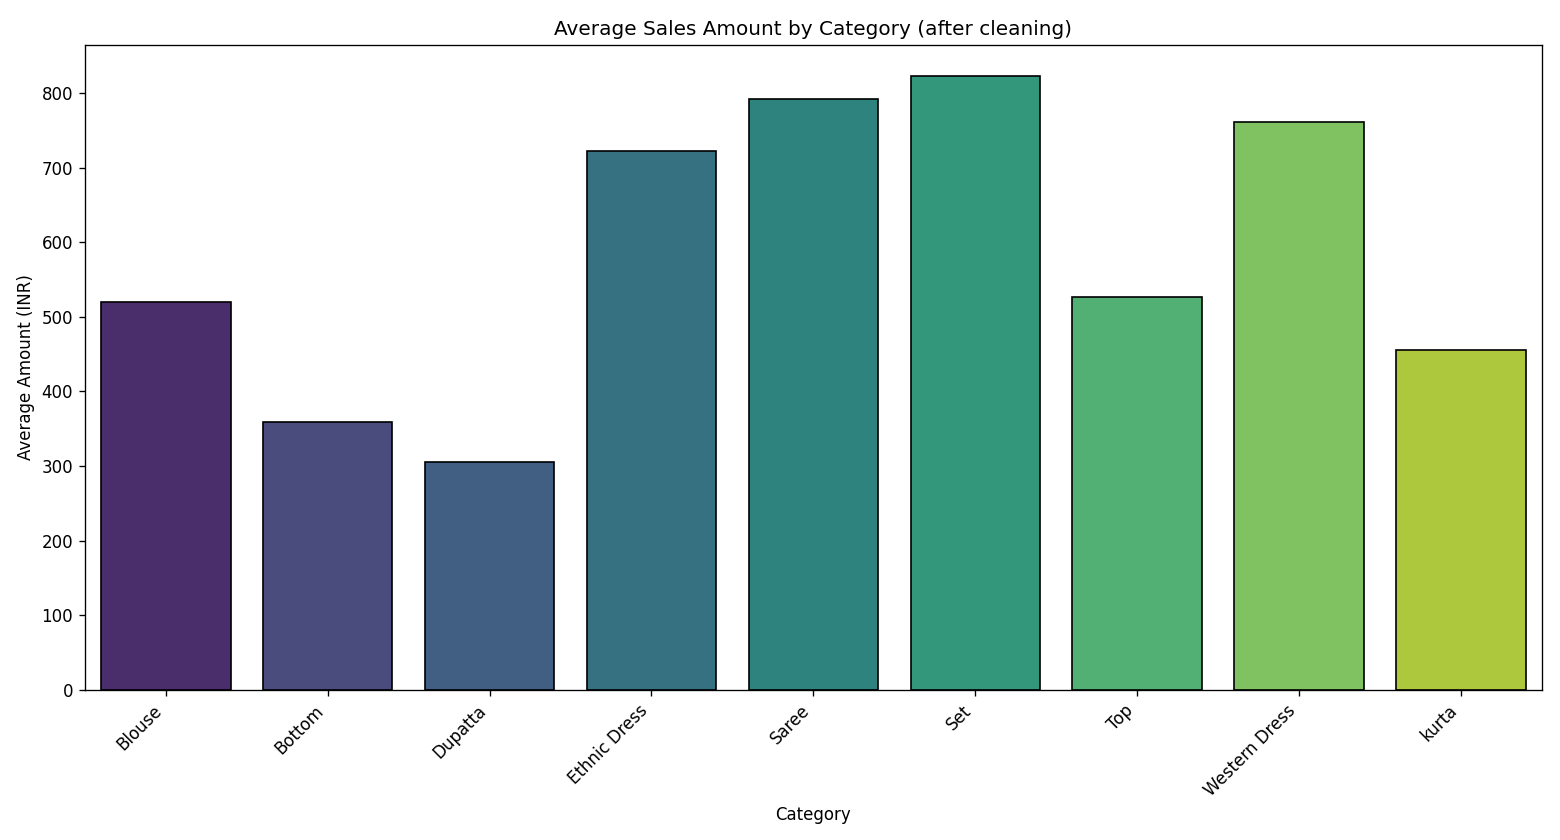

In [ ]:
grop_me = df.groupby("category")["amount"].agg("mean").reset_index()
print(grop_me)

plt.figure(figsize=(13, 7))
sns.barplot(x="category", y="amount", data=grop_me, edgecolor="black")
plt.title("Average Sales Amount by Category (after cleaning)")
plt.xlabel("Category")
plt.ylabel("Average Amount (INR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/12_avg_sales_by_category.png", dpi=120)
plt.show()


## 17. Final summary

In [4]:
df["amount"].describe()

count    128975.000000
mean        644.541944
std         263.135780
min           0.000000
25%         455.927108
50%         612.000000
75%         788.000000
max        1286.109338
Name: amount, dtype: float64


In [5]:
df.shape

(128975, 23)

## Conclusions (in plain words)

- Most orders end up **Shipped**; a smaller share are **Cancelled**, and only a tiny fraction get stuck as **Pending / Lost / RTO**.
- **Merchant**-fulfilled orders have a noticeably higher cancellation rate than Amazon-fulfilled orders.
- **Set**, **kurta**, and **Western Dress** are the categories that bring in the most total sales.
- Orders are heavily concentrated in **April–June 2022**, with very few in March.
- **Maharashtra** and **Karnataka** are the top two states by total sales.
- `qty` and `amount` both had some extreme outliers, which we capped using the IQR rule so they don't distort the averages and charts.